# Job Shop Scheduling Problem: ROA Group 20 (JSSP) 

# Trajectory based - Hill Climbing



# 1. Imports

In [42]:
import numpy as np 
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import time
import random



# 2. Read instance from jobshop.txt


In [43]:
def parse_instance(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    lines = [line.strip() for line in lines if line.strip()]

    for i, line in enumerate(lines):
        if line[0].isdigit():
            jobs, machines = map(int, line.split())
            start_index = i + 1
            break

    jobs_data = []
    for line in lines[start_index:start_index + jobs]:
        numbers = list(map(int, line.split()))
        operations = []
        for i in range(0, len(numbers), 2):
            machine = numbers[i]
            duration = numbers[i + 1]
            operations.append((machine, duration))
        jobs_data.append(operations)

    return jobs, machines, jobs_data

# 3. Makespan calculator

In [44]:
def makespan(chromosome, jobs, n_machines):
    n_jobs      = len(jobs)
    job_step    = [0] * n_jobs
    job_end     = [0] * n_jobs
    machine_end = [0] * n_machines
    schedule    = defaultdict(list)

    for job in chromosome:
        step = job_step[job]
        if step >= len(jobs[job]):
            continue
        machine, duration = jobs[job][step]
        start  = max(job_end[job], machine_end[machine])
        finish = start + duration
        schedule[machine].append((job, start, finish))
        machine_end[machine] = finish
        job_end[job]         = finish
        job_step[job]       += 1

    return max(machine_end), dict(schedule)


def random_chromosome(n_jobs, n_machines):
    chrom = [j for j in range(n_jobs) for _ in range(n_machines)]
    np.random.shuffle(chrom)
    return chrom


# 4. Operators (swap, insert, reverse a segment)

In [45]:
def swap_adjacent(chrom):
    c = chrom[:]
    i = random.randrange(len(c) - 1)
    c[i], c[i+1] = c[i+1], c[i]
    return c


def insert_move(chrom):
    c = chrom[:]
    i = random.randrange(len(c))
    j = random.randrange(len(c))
    elem = c.pop(i)
    c.insert(j, elem)
    return c


def reverse_segment(chrom):
    c = chrom[:]
    i, j = sorted(random.sample(range(len(c)), 2))
    c[i:j+1] = c[i:j+1][::-1]
    return c


OPERATORS = [swap_adjacent, insert_move, reverse_segment]

# 5. HC Agorithm

In [46]:
def hill_climbing(jobs, n_jobs, n_machines,
                  max_iter=10_000,
                  operator=None):

    current    = random_chromosome(n_jobs, n_machines)
    current_ms = makespan(current, jobs, n_machines)[0]
    history    = [current_ms]

    for _ in range(max_iter):
        op        = operator if operator else random.choice(OPERATORS)
        neighbour = op(current)
        nb_ms     = makespan(neighbour, jobs, n_machines)[0]

        if nb_ms <= current_ms:
            current    = neighbour
            current_ms = nb_ms

        history.append(current_ms)

    return current, current_ms, history


def random_restart_hill_climbing(jobs, n_jobs, n_machines,
                                  max_iter=10_000,
                                  n_restarts=10):

    iters_per_restart = max(1, max_iter // n_restarts)
    best_chrom   = None
    best_ms      = float('inf')
    full_history = []

    for restart in range(n_restarts):
        chrom, ms, hist = hill_climbing(
            jobs, n_jobs, n_machines,
            max_iter=iters_per_restart
        )
        full_history.extend(hist)

        if ms < best_ms:
            best_ms    = ms
            best_chrom = chrom[:]

    return best_chrom, best_ms, full_history


# 6 Run code


=== Instance abz5 ===
Jobs: 10 | Machines: 10 | Optimal: 1234
Single HC over 25 runs: best =   1234 | avg = 1272.5 | time/run = 0.81s
Random-Restart HC over 25 runs: best =   1260 | avg = 1279.1 | time/run = 0.77s
HC (swap_adjacent       ) best =   1287 | avg = 1391.2 | time/run = 0.72s
HC (insert_move         ) best =   1234 | avg = 1262.8 | time/run = 0.73s
HC (reverse_segment     ) best =   1242 | avg = 1295.6 | time/run = 0.81s


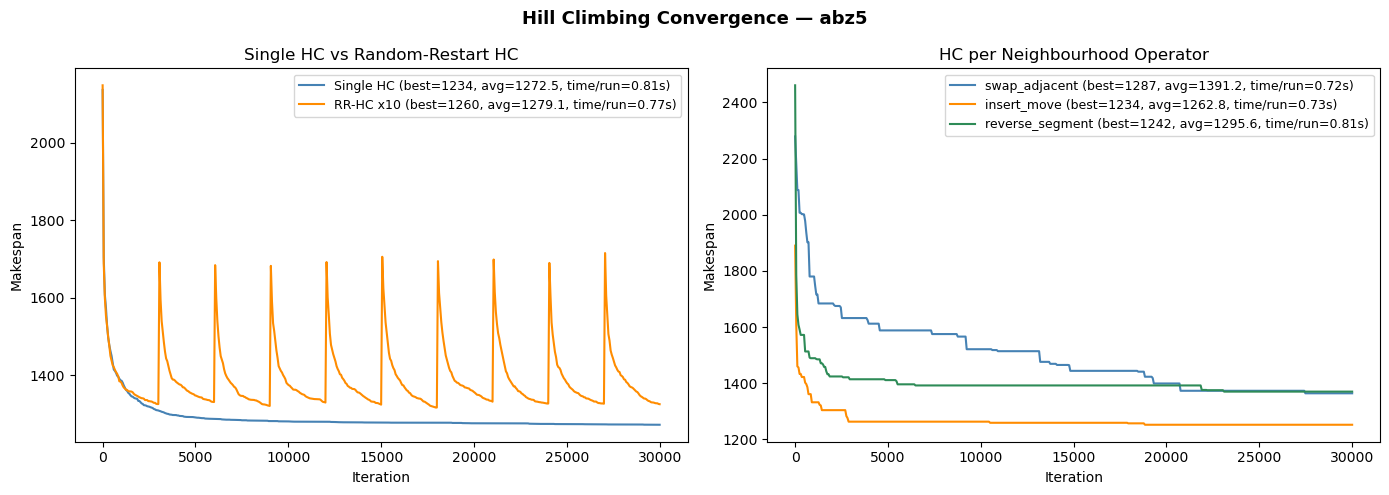

Over 25 runs:
  Best  : 1242
  Worst : 1325
  Mean  : 1273.0
  Std   : 22.8
  Avg gap from optimal: 3.2%


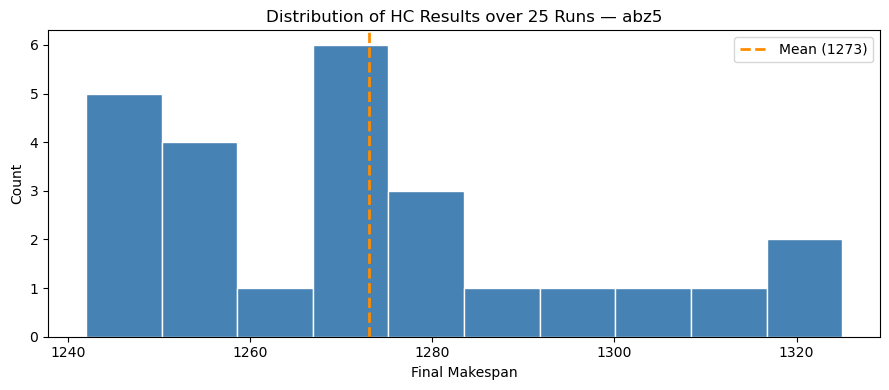


=== Instance abz6 ===
Jobs: 10 | Machines: 10 | Optimal: 943
Single HC over 25 runs: best =    945 | avg =  974.2 | time/run = 0.82s
Random-Restart HC over 25 runs: best =    952 | avg =  973.5 | time/run = 0.79s
HC (swap_adjacent       ) best =    995 | avg = 1091.1 | time/run = 0.73s
HC (insert_move         ) best =    947 | avg =  969.8 | time/run = 0.76s
HC (reverse_segment     ) best =    957 | avg =  988.3 | time/run = 0.82s


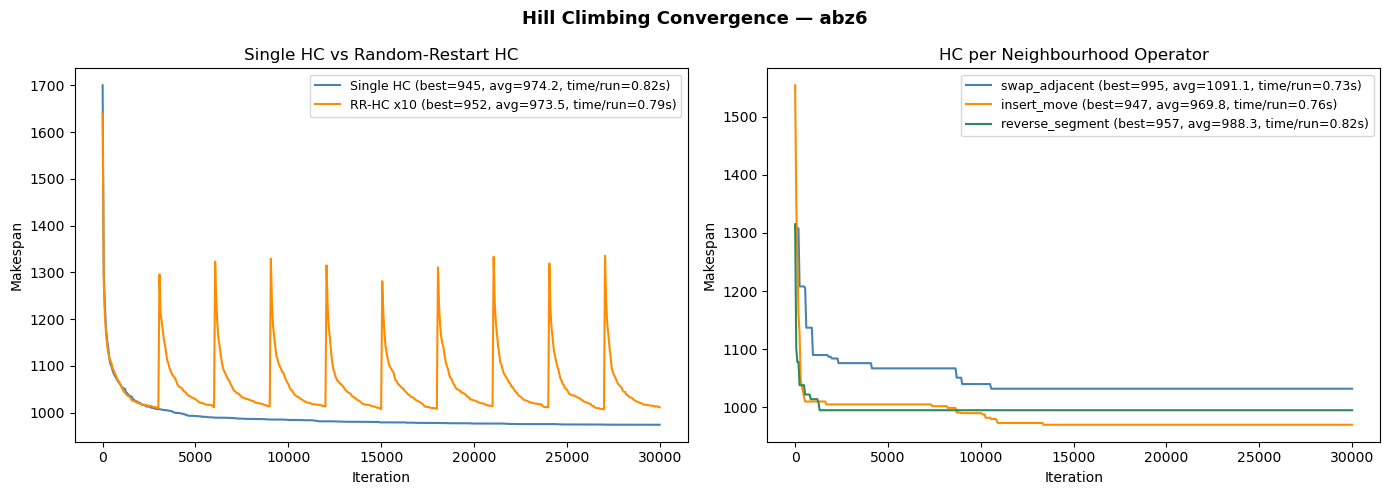

Over 25 runs:
  Best  : 943
  Worst : 1005
  Mean  : 967.7
  Std   : 18.8
  Avg gap from optimal: 2.6%


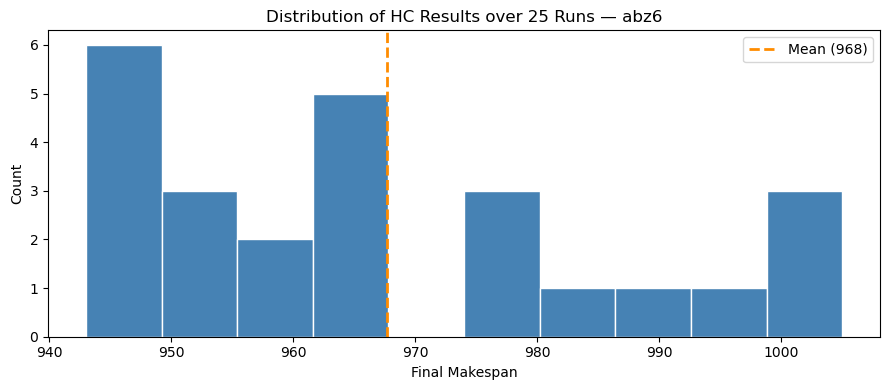


=== Instance abz7 ===
Jobs: 20 | Machines: 15 | Optimal: 656
Single HC over 25 runs: best =    714 | avg =  736.8 | time/run = 2.09s
Random-Restart HC over 25 runs: best =    784 | avg =  802.0 | time/run = 2.09s
HC (swap_adjacent       ) best =    836 | avg =  946.5 | time/run = 2.00s
HC (insert_move         ) best =    697 | avg =  718.2 | time/run = 2.00s
HC (reverse_segment     ) best =    765 | avg =  794.7 | time/run = 2.10s


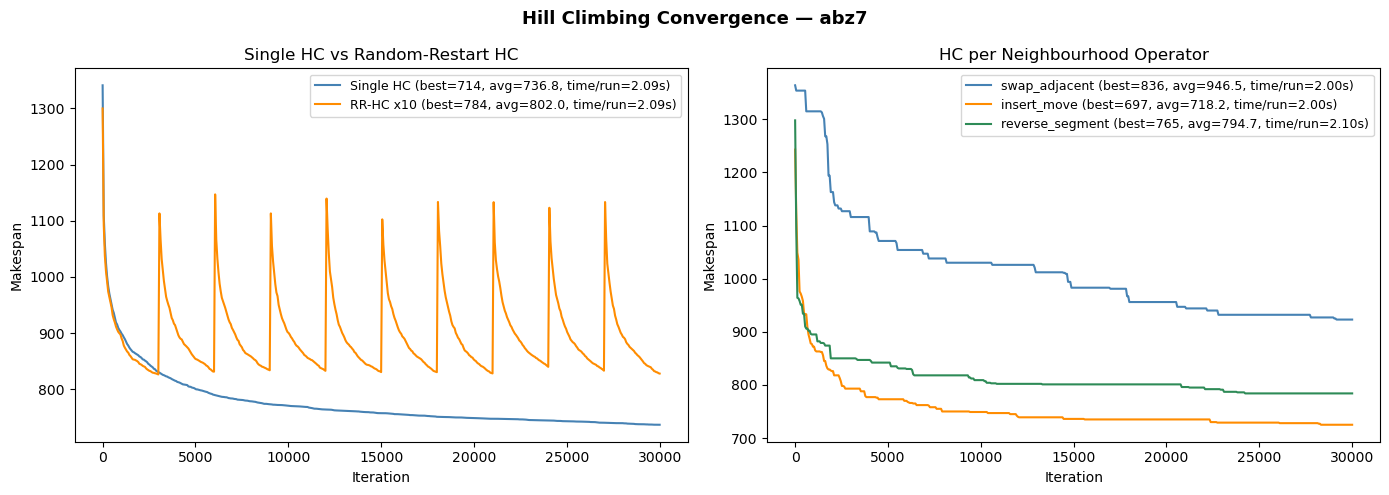

Over 25 runs:
  Best  : 719
  Worst : 761
  Mean  : 738.6
  Std   : 11.5
  Avg gap from optimal: 12.6%


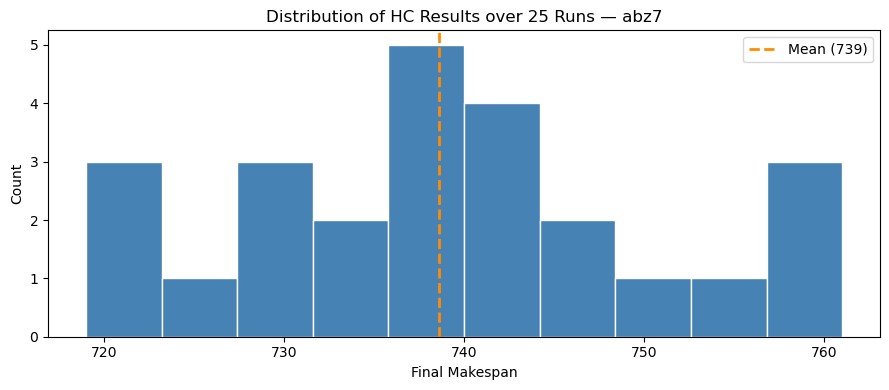

In [47]:
KNOWN_OPTIMAL = {
    'ft06': 55, 'ft10': 930, 'ft20': 1165,
    'la01': 666, 'la02': 655, 'la03': 597,
    'abz5': 1234, 'abz6': 943, 'abz7': 656,  # add if known
}

MAX_ITER = 30_000
RESTARTS = 10
N_RUNS  = 25
HC_RR_RUNS = 25

def run_hc_suite(file_path, label):
    n_jobs, n_machines, jobs = parse_instance(file_path)
    opt = KNOWN_OPTIMAL.get(label)

    print(f"\n=== Instance {label} ===")
    print(f"Jobs: {n_jobs} | Machines: {n_machines} | Optimal: {opt}")

    # 1) Single HC (averaged over HC_RR_RUNS)
    hc_histories = []
    hc_makespans = []
    hc_times = []
    for _ in range(HC_RR_RUNS):
        t0 = time.time()
        _, hc_ms, hc_hist = hill_climbing(jobs, n_jobs, n_machines, max_iter=MAX_ITER)
        hc_times.append(time.time() - t0)
        hc_makespans.append(hc_ms)
        hc_histories.append(hc_hist)

    hc_best = min(hc_makespans)
    hc_avg = np.mean(hc_makespans)
    hc_time_avg = np.mean(hc_times)
    hc_hist_avg = [np.mean(vals) for vals in zip(*hc_histories)]

    print(f"Single HC over {HC_RR_RUNS} runs: best = {hc_best:6d} | avg = {hc_avg:6.1f} | time/run = {hc_time_avg:.2f}s")

    # 2) Random-Restart HC (averaged over HC_RR_RUNS)
    rr_histories = []
    rr_makespans = []
    rr_times = []
    for _ in range(HC_RR_RUNS):
        t0 = time.time()
        _, rr_ms, rr_hist = random_restart_hill_climbing(
            jobs, n_jobs, n_machines, max_iter=MAX_ITER, n_restarts=RESTARTS
        )
        rr_times.append(time.time() - t0)
        rr_makespans.append(rr_ms)
        rr_histories.append(rr_hist)

    rr_best = min(rr_makespans)
    rr_avg = np.mean(rr_makespans)
    rr_time_avg = np.mean(rr_times)
    rr_hist_avg = [np.mean(vals) for vals in zip(*rr_histories)]

    print(f"Random-Restart HC over {HC_RR_RUNS} runs: best = {rr_best:6d} | avg = {rr_avg:6.1f} | time/run = {rr_time_avg:.2f}s")

    # 3) Per-operator HC
    op_results = {}
    for op in OPERATORS:
        op_run_results = []
        op_hist_sample = None
        op_times = []  # ADDED

        for _ in range(N_RUNS):
            t0 = time.time()  # ADDED
            _, op_ms, op_hist = hill_climbing(
                jobs, n_jobs, n_machines, max_iter=MAX_ITER, operator=op
            )
            op_times.append(time.time() - t0)  # ADDED
            op_run_results.append(op_ms)
            if op_hist_sample is None:
                op_hist_sample = op_hist

        op_best = min(op_run_results)
        op_avg = np.mean(op_run_results)
        op_time_avg = np.mean(op_times)  # ADDED

        op_results[op.__name__] = (op_best, op_avg, op_time_avg, op_hist_sample)  # CHANGED
        print(f"HC ({op.__name__:<20}) best = {op_best:6d} | avg = {op_avg:6.1f} | time/run = {op_time_avg:.2f}s")  # CHANGED


    # Plot convergence
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Hill Climbing Convergence — {label}", fontsize=13, fontweight='bold')

    ax = axes[0]
    step = max(1, len(hc_hist_avg) // 500)
    ax.plot(range(0, len(hc_hist_avg), step),
            [hc_hist_avg[i] for i in range(0, len(hc_hist_avg), step)],
            color='steelblue', lw=1.5,
            label=f'Single HC (best={hc_best}, avg={hc_avg:.1f}, time/run={hc_time_avg:.2f}s)')  # CHANGED
    step2 = max(1, len(rr_hist_avg) // 500)
    ax.plot(range(0, len(rr_hist_avg), step2),
            [rr_hist_avg[i] for i in range(0, len(rr_hist_avg), step2)],
            color='darkorange', lw=1.5,
            label=f'RR-HC x{RESTARTS} (best={rr_best}, avg={rr_avg:.1f}, time/run={rr_time_avg:.2f}s)')  # CHANGED
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Makespan")
    ax.set_title("Single HC vs Random-Restart HC")
    ax.legend(fontsize=9)

    ax = axes[1]
    colors = ['steelblue', 'darkorange', 'seagreen']
    for (name, (best_ms, avg_ms, time_avg, hist)), color in zip(op_results.items(), colors):  # CHANGED
        step = max(1, len(hist) // 500)
        ax.plot(range(0, len(hist), step),
                [hist[i] for i in range(0, len(hist), step)],
                color=color, lw=1.5,
                label=f'{name} (best={best_ms}, avg={avg_ms:.1f}, time/run={time_avg:.2f}s)')  # CHANGED
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Makespan")
    ax.set_title("HC per Neighbourhood Operator")
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # Distribution over runs
    run_results = []
    for _ in range(N_RUNS):
        _, ms, _ = hill_climbing(jobs, n_jobs, n_machines, max_iter=MAX_ITER)
        run_results.append(ms)

    print(f"Over {N_RUNS} runs:")
    print(f"  Best  : {min(run_results)}")
    print(f"  Worst : {max(run_results)}")
    print(f"  Mean  : {np.mean(run_results):.1f}")
    print(f"  Std   : {np.std(run_results):.1f}")
    if opt:
        gaps = [(r - opt) / opt * 100 for r in run_results]
        print(f"  Avg gap from optimal: {np.mean(gaps):.1f}%")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(run_results, bins=10, color='steelblue', edgecolor='white')
    ax.axvline(np.mean(run_results), color='darkorange', ls='--', lw=2,
               label=f'Mean ({np.mean(run_results):.0f})')
    ax.set_xlabel("Final Makespan")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of HC Results over {N_RUNS} Runs — {label}")
    ax.legend()
    plt.tight_layout()
    plt.show()


instances = [
    ("abz5.txt", "abz5"),
    ("abz6.txt", "abz6"),
    ("abz7.txt", "abz7"),
]

for path, label in instances:
    run_hc_suite(path, label)
